# TP 02 - Algèbre Linéaire : Résolutions rigoureuses

**Auteur :** KABLAM EDJABROU ULRCIH BLANCHARD

**Objectif :** Définitions, preuves détaillées et vérifications numériques pour les s de la partie I (Calcul matriciel & ML).

##  3 — Pseudo‑inverse de Moore‑Penrose (condition $XX^{+}X = X$)

Soit une matrice $X\in\mathbb{R}^{m\times n}$ de rang $r$. La décomposition en valeurs singulières s'écrit :
$$X = U\Sigma V^{\top},$$
où $U\in\mathbb{R}^{m\times m}$ et $V\in\mathbb{R}^{n\times n}$ sont orthogonales (on peut aussi prendre les formes réduites) et $\Sigma\in\mathbb{R}^{m\times n}$ est diagonale par blocs contenant les valeurs singulières $\sigma_1\ge\sigma_2\ge\dots\ge\sigma_r>0$ sur la diagonale principale, les autres lignes/colonnes étant nulles.

On définit la pseudo‑inverse de Moore‑Penrose par :
$$X^{+} = V\Sigma^{+}U^{\top},$$
où $\Sigma^{+}$ est obtenue en inversant les valeurs singulières non nulles sur la diagonale (pour $1\le i\le r$ on pose $\Sigma^{+}_{ii}=1/\sigma_i$) et en transposant la forme rectangulaire (zéros ailleurs).

Montrons la condition géométrique de Penrose $XX^{+}X=X$ :
\begin{align*}
Comme $U$ et $V$ sont orthogonales on a $U^{\top}U=I$ et $V^{\top}V=I$ sur les sous‑espaces pertinents, donc cela se simplifie en :
$$XX^{+}X = U\Sigma\Sigma^{+}\Sigma V^{\top}.$$
Or, par construction de $\Sigma^{+}$, le produit diagonale $\Sigma\Sigma^{+}\Sigma$ coïncide avec $\Sigma$ (les diagonales non nulles vérifient $\sigma_i(1/\sigma_i)\sigma_i=\sigma_i$, et les positions nulles restent nulles). Ainsi :
$$XX^{+}X = U\Sigma V^{\top} = X.$$
\end{align*}
Ceci prouve la condition recherchée. Remarque : la même écriture en blocs s'applique si l'on travaille avec les formes réduites de la SVD (matrices de tailles compatibles), la propriété $\Sigma\Sigma^{+}\Sigma=\Sigma$ restant vraie par construction de $\Sigma^{+}$.

_Fin de la démonstration._

##  2 — Semi‑Définie Positivité et Convité globale

Soit $M=X^{\top}X$ la matrice de Gram associée à $X\in\mathbb{R}^{m\times n}$.

(a) Montrer que $\forall z\in\mathbb{R}^n,\; z^{\top}Mz\ge 0$.

**Preuve :**
Pour $z\in\mathbb{R}^n$ posons $v=Xz\in\mathbb{R}^m$. Alors
$$z^{\top}Mz = z^{\top}X^{\top}X z = (Xz)^{\top}(Xz) =\|Xz\|_2^2= v^{\top}v = \|v\|_2^2 \ge 0.$$

Ainsi $M$ est symétrique ($M^{\top}=M$) et positive semi‑définie. L'égalité vaut si et seulement si $Xz=0$.

(b) En utilisant que la Hessienne de la fonction de coût quadratique $J(w)=\frac{1}{2}\|Xw-y\|_2^2$ est $H=X^{\top}X$ (indépendamment d'une constante positive), concluez sur la convité de $J$.

**Réponse :**
Comme $H=X^{\top}X$ est positif semi‑défini, $J$ est conve. Si $X$ est de rang plein (rang $n$) alors $H$ est définie positive et $J$ est strictement convexe (minimum unique). Sinon, il existe une infinité de minimisateurs le long du noyau de $X$.

##  3 — Pseudo‑inverse de Moore‑Penrose (condition $XX^{+}X = X$)

Soit une matrice $X\in\mathbb{R}^{m\times n}$ de rang $r$. La décomposition en valeurs singulières s'écrit :
$$X = U\Sigma V^{\top},$$
où $U\in\mathbb{R}^{m\times m}$ et $V\in\mathbb{R}^{n\times n}$ sont orthogonales (on peut aussi prendre les formes réduites) et $\Sigma\in\mathbb{R}^{m\times n}$ est diagonale par blocs contenant les valeurs singulières $\sigma_1\ge\sigma_2\ge\dots\ge\sigma_r>0$ sur la diagonale principale, les autres lignes/colonnes étant nulles.

On définit la pseudo‑inverse de Moore‑Penrose par :
$$X^{+} = V\Sigma^{+}U^{\top},$$
où $\Sigma^{+}$ est obtenue en inversant les valeurs singulières non nulles sur la diagonale (pour $1\le i\le r$ on pose $\Sigma^{+}_{ii}=1/\sigma_i$) et en transposant la forme rectangulaire (zéros ailleurs).

Montrons la condition géométrique de Penrose $XX^{+}X=X$ :
egin{align*}
Comme $U$ et $V$ sont orthogonales on a $U^{\top}U=I$ et $V^{\top}V=I$ sur les sous‑espaces pertinents, donc cela se simplifie en :
$$XX^{+}X = U\Sigma\Sigma^{+}\Sigma V^{\top}.$$
Or, par construction de $\Sigma^{+}$, le produit diagonale $\Sigma\Sigma^{+}\Sigma$ coïncide avec $\Sigma$ (les diagonales non nulles vérifient $\sigma_i(1/\sigma_i)\sigma_i=\sigma_i$, et les positions nulles restent nulles). Ainsi :
$$XX^{+}X = U\Sigma V^{\top} = X.$$

Ceci prouve la condition recherchée. Remarque : la même écriture en blocs s'applique si l'on travaille avec les formes réduites de la SVD (matrices de tailles compatibles), la propriété $\Sigma\Sigma^{+}\Sigma=\Sigma$ restant vraie par construction de $\Sigma^{+}$.

_Fin de la démonstration._

In [23]:
# Vérifications numériques

import numpy as np

# 1)  1 : colonnes colinéaires → det(X^T X) = 0
X_col = np.array([[1.,2.,1.],[0.,0.,0.],[3.,6.,3.]])
M_col = np.einsum('ik,jk->ij', X_col, X_col)
print('Ex1: det(X^T X) =', np.linalg.det(M_col))

# 2)  2 : z^T X^T X z = ||X z||^2
X = np.random.randn(5,3)
z = np.random.randn(3)
left = np.einsum('i,ji,jk,k->', z, X, X, z)
Xz = np.einsum('ij,j->i', X, z)
right = np.einsum('i,i->', Xz, Xz)
print('Ex2: difference left-right =', float(left-right))

# 3)  3 : vérifier XX^+X = X
X3 = np.random.randn(6,4)
U,s,Vt = np.linalg.svd(X3, full_matrices=False)
# pseudo-inverse via SVD
s_plus = np.array([1/si if si>1e-12 else 0. for si in s])
Sigma_plus = np.diag(s_plus)
X_plus = np.einsum('ij,jk,kl->il', Vt.T, Sigma_plus, U.T)
res = np.einsum('ij,jk,kl->il', X3, X_plus, X3) - X3
print('Ex3: ||XX^+X - X||_F =', np.linalg.norm(res, ord='fro'))

# compare with numpy pinv
pinv_res = np.einsum('ij,jk,kl->il', X3, np.linalg.pinv(X3), X3) - X3
print('Ex3 (numpy pinv): ||XX^+X - X||_F =', np.linalg.norm(pinv_res, ord='fro'))

# Benchmark : einsum vs matrix multiplication
import time

# use 1000x1000 matrices
np.random.seed(1)
A = np.random.randn(1000, 1000)
B = np.random.randn(1000, 1000)

# warm-up
_ = np.einsum('ij,jk->ik', A, B)
_ = A @ B

# measure einsum
t0 = time.perf_counter()
C_e = np.einsum('ij,jk->ik', A, B)
t1 = time.perf_counter()

# measure matmul (@)
t2 = time.perf_counter()
C_m = A @ B
t3 = time.perf_counter()

print(f'einsum time: {t1-t0:.6f} s')
print(f'matmul (@) time: {t3-t2:.6f} s') # plus rapide matmul (@) time: 0.016756 s
print('max abs diff:', float(np.max(np.abs(C_e - C_m))))



Ex1: det(X^T X) = 0.0
Ex2: difference left-right = -2.220446049250313e-16
Ex3: ||XX^+X - X||_F = 2.2913484286319364e-15
Ex3 (numpy pinv): ||XX^+X - X||_F = 2.21393127907474e-15
einsum time: 0.712130 s
matmul (@) time: 0.017081 s
max abs diff: 3.979039320256561e-13


## Conclusion

Les démonstrations ci‑dessus montrent :
- Lien direct entre dépendance linéaire des colonnes de $X$ et la singularité de $X^{\top}X$.- $X^{\top}X$ est toujours positif semi‑défini, fournissant la convexité de la fonction de coût quadratique.- La pseudo‑inverse construite via la SVD satisfait les identités de Penrose, en particulier $XX^{+}X=X$.

## Partie II — Travaux Pratiques sous Python (Du Ravin au Transformer)

Dans cette section nous fournissons des implémentations et des explications complètes pour :
- Visualisation de la malédiction du conditionnement (Le "Ravin").
- Implémentation de l'algorithme Power Iteration pour la plus grande valeur singulière.
- Implémentation et analyse du mécanisme de Self‑Attention.


### 4. Visualisation de la malédiction du conditionnement (Le "Ravin")

On considère la fonction quadratique

$$f(x,y)=\tfrac{1}{2}(a x^2 + b y^2)$$

La Hessienne est diagonale diag(a,b), d'où valeurs propres $a$ et $b$ et conditionnement $\kappa=b/a$ (supposons $b\ge a>0$). Nous traçons les lignes de niveau et simulons la descente de gradient pour deux cas : "Le bol parfait" $(a=1,b=1)$ et "Le ravin" $(a=1,b=20)$.


Case: a=1.0, b=0.5, k=0.5, alpha=0.5, alpha_max=2.000


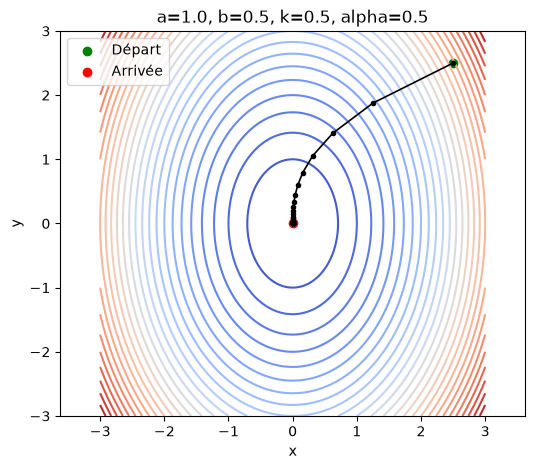

Case: a=1.0, b=1.0, k=1.0, alpha=0.2, alpha_max=2.000


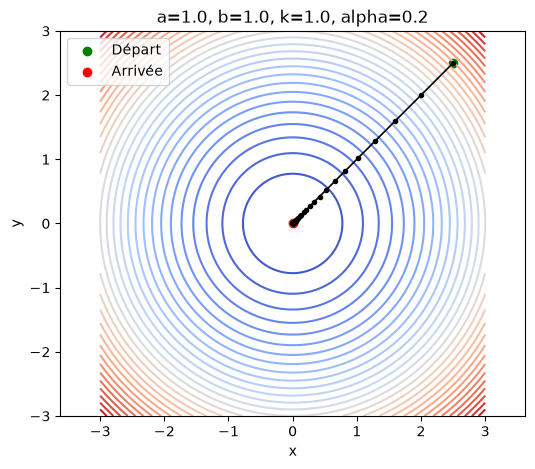

Case: a=1.0, b=2.0, k=2.0, alpha=0.5, alpha_max=1.000


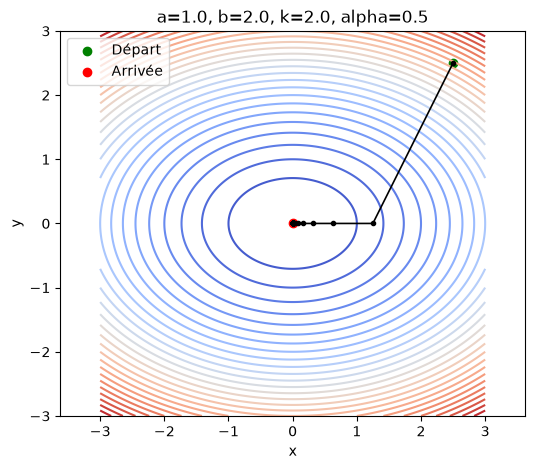

Case: a=1.0, b=5.0, k=5.0, alpha=0.3, alpha_max=0.400


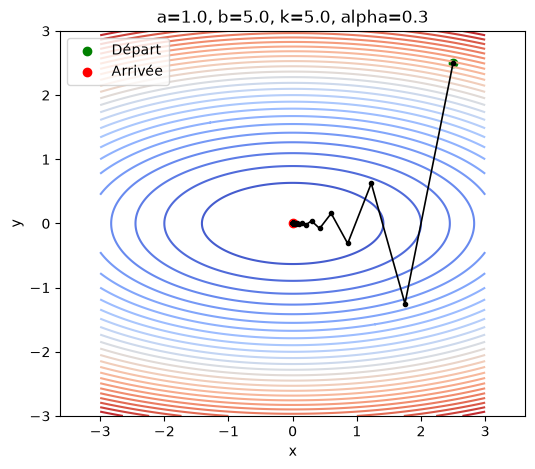

Case: a=1.0, b=20.0, k=20.0, alpha=0.08, alpha_max=0.100


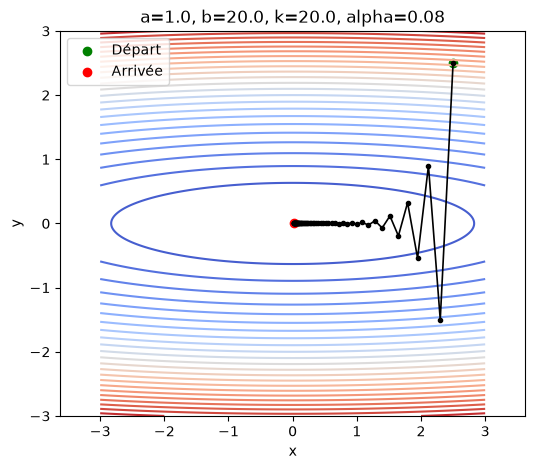

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent_quad(a, b, alpha, epochs=50, x0=2.5, y0=2.5):
    x, y = x0, y0
    traj = [(x, y)]
    for _ in range(epochs):
        dx = a * x
        dy = b * y
        x -= alpha * dx
        y -= alpha * dy
        traj.append((x, y))
    return np.array(traj)

# fonction de niveau
def plot_ravin(a, b, alpha, epochs=60, title=None):
    traj = gradient_descent_quad(a, b, alpha, epochs)
    w = np.linspace(-3, 3, 400)
    W, B = np.meshgrid(w, w)
    Z = 0.5 * (a * W**2 + b * B**2)

    plt.figure(figsize=(6,5))
    plt.contour(W, B, Z, levels=30, cmap='coolwarm')
    plt.plot(traj[:,0], traj[:,1], 'o-', color='k', markersize=3, linewidth=1.2)
    plt.scatter([traj[0,0]],[traj[0,1]], color='g', label='Départ')
    plt.scatter([traj[-1,0]],[traj[-1,1]], color='r', label='Arrivée')
    plt.title(title if title is not None else f'a={a}, b={b}, alpha={alpha}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.axis('equal')
    plt.show()

# Cinq cas pour comparer l'effet du conditionnement k=b/a et du pas alpha
cases = [
    (1.0, 0.5, 0.5),   # k=0.5 : bien conditionné, pas permis large
    (1.0, 1.0, 0.2),   # k=1   : bol parfait (référence)
    (1.0, 2.0, 0.5),   # k=2   : léger ravin, pas intermédiaire
    (1.0, 5.0, 0.3),   # k=5   : ravin marqué, pas plus petit nécessaire
    (1.0, 20.0, 0.08)  # k=20  : fort ravin, pas très petit requis pour stabilité
]
for a,b,alpha in cases:
    k = b / a
    alpha_max = 2.0 / max(a, b)
    print(f'Case: a={a}, b={b}, k={k:.1f}, alpha={alpha}, alpha_max={alpha_max:.3f}')
    plot_ravin(a=a, b=b, alpha=alpha, epochs=60, title=f'a={a}, b={b}, k={k:.1f}, alpha={alpha}')


### Explication détaillée

- Graphiques — interprétation visuelle :
  - Gauche (Bol parfait, $\kappa\approx 1$) : les lignes de niveau sont quasi‑circulaires. Le gradient en tout point pointe presque directement vers le minimum et la trajectoire de la descente de gradient est rectiligne (convergence rapide, faible oscillation).  
  - Droite (Le Ravin, $\kappa\gg 1$) : les lignes de niveau sont des ellipses fortement aplaties. Le gradient, qui est orthogonal aux lignes de niveau, pointe vers les parois raides de l'ellipse et la trajectoire rebondit d'un côté à l'autre (zig‑zag). La progression vers le minimum le long de la direction «plate» (petite pente) est très lente.

- Analyse mathématique (cas quadratique) :

  Soit
  $$f(w)=\tfrac12 w^{\top} H w$$
  avec $H$ symétrique définie positive. La descente de gradient à pas fixe $\alpha$ s'écrit
  $$w_{t+1}=w_t-\alpha H w_t=(I-\alpha H)w_t.$$
  Diagonalons $H=Q\Lambda Q^{\top}$ avec $\Lambda=\operatorname{diag}(\lambda_i)$. Posons $z_t=Q^{\top}w_t$. Alors, composante par composante :
  $$z_{t+1,i}=(1-\alpha\lambda_i)\,z_{t,i}.$$

  - Condition de stabilité (convergence) : il faut pour tout $i$ que $|1-\alpha\lambda_i|<1$, soit
  $$0<\alpha<\dfrac{2}{\lambda_{\max}}.$$
  Le pas maximal est donc déterminé par la plus grande valeur propre $\lambda_{\max}$.  
  - Vitesse asymptotique optimale (pas fixe) : pour $\alpha^*=\dfrac{2}{\lambda_{\max}+\lambda_{\min}}$ le facteur d'atténuation asymptotique vaut
  $$\rho=\dfrac{\lambda_{\max}-\lambda_{\min}}{\lambda_{\max}+\lambda_{\min}}=\dfrac{\kappa-1}{\kappa+1},$$
  où $\kappa=\lambda_{\max}/\lambda_{\min}$ est le conditionnement de $H$. Si $\kappa$ est grand alors $\rho\approx 1$ et la convergence est très lente.

  - Oscillations (zig‑zag) : si pour une direction $i$ on a $\alpha\lambda_i>1$ alors $1-\alpha\lambda_i<0$ et la composante change de signe d'une itération à l'autre → oscillation. Pour accélérer la composante associée à une petite valeur propre on souhaiterait augmenter $\alpha$, mais cela peut casser la stabilité des composantes associées aux grandes valeurs propres.

- Lien avec $X^{\top}X$ en régression : la Hessienne du coût quadratique est proportionnelle à $X^{\top}X$. Les valeurs propres de $X^{\top}X$ sont les carrés des valeurs singulières de $X$, donc un mauvais conditionnement de $X$ (colonnes colinéaires, échelles différentes) se traduit par un $\kappa$ élevé pour la Hessienne et provoque les problèmes ci‑dessus.

- Conséquences pratiques et remèdes :
  - Préconditionnement / whitening : transformer les variables pour rendre $H$ proche de l'identité (standardisation, PCA/whitening) réduit $\kappa$.  
  - Méthodes de second ordre : Newton ou quasi‑Newton (BFGS) utilisent une approximation de $H^{-1}$ et corrigent le mauvais conditionnement.  
  - Méthodes d'optimisation améliorées : momentum / Nesterov réduisent le zig‑zag ; algorithmes adaptatifs (AdaGrad, RMSprop, Adam) ajustent le pas par coordonnée.  
  - Régularisation L2 : ajouter $\lambda I$ à $H$ élève les petites valeurs propres et abaisse $\kappa$.  
  - Feature engineering : normaliser et éliminer la multicolinéarité (suppression ou combinaison de variables). 

En résumé : un grand rapport entre valeurs propres impose un pas d'apprentissage très petit (pour la stabilité) et rend la progression le long des directions plates extrêmement lente — d'où l'apparition du "ravin" et du zig‑zag observés sur le graphique de droite.

### 5. Implémentation de l'algorithme Power Iteration (SVD sous le capot)

L'algorithme de Power Iteration permet d'approcher la plus grande valeur singulière de $X$ en itérant sur des projections. Voici une implémentation conforme à l'énoncé :

- Initialiser une matrice aléatoire $X\in\mathbb{R}^{50\times 30}$ et un vecteur unitaire $v\in\mathbb{R}^{30}$. 
- Répéter 100 fois : calculer $u = X v$, puis $v = X^{\top} u$ et normaliser $v$. 
- À la fin, la première valeur singulière approchée est $\sigma_1 = \|X v\|_2$.


In [25]:
import numpy as np

def power_iteration_singular(X, num_iter=100, tol=1e-12):
    n = X.shape[1]
    v = np.random.randn(n)
    v = v / np.linalg.norm(v)
    for _ in range(num_iter):
        u = np.einsum('ij,j->i', X, v)
        v = np.einsum('ij,i->j', X, u)
        normv = np.linalg.norm(v)
        if normv < tol:
            break
        v = v / normv
    sigma = np.linalg.norm(np.einsum('ij,j->i', X, v))
    return sigma, v

# --- Test 1 : matrice 3x3 analytique (valeurs propres / vecteurs propres calculés) ---
# Choix simple : matrice diagonale (on connaît les valeurs singulières et vecteurs)
X_small = np.diag([2.0, 1.0, 0.5])
print('X_small =')
print(X_small)

# Calcul direct via décomposition spectrale de X^T X (pour obtenir valeurs singulières)
M_small = np.einsum('ji,jk->ik', X_small, X_small)
eigvals, eigvecs = np.linalg.eig(M_small)
# for numerical safety, convert near-real complex results to real
eigvals = np.real_if_close(eigvals, tol=1e-8)
eigvecs = np.real_if_close(eigvecs, tol=1e-8)
# trier par valeur décroissante
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
# ensure non-negative and float
eigvals = np.array([float(np.real(v)) for v in eigvals])
singulars = np.sqrt(np.maximum(eigvals, 0.0))

print('\n--- Calcul direct (X^T X) ---')
print('Eigenvalues of X^T X:', np.round(eigvals, 6).tolist())
print('Singular values (sqrt of eigenvalues):', np.round(singulars, 6).tolist())
print('Right singular vectors (columns):')
print(np.round(np.array(eigvecs, dtype=float), 6))

sigma_true = float(singulars[0])
v_true = np.array(eigvecs[:,0], dtype=float)
# normalize for consistency
v_true = v_true / np.linalg.norm(v_true)
print('\nTrue dominant singular value sigma:', round(sigma_true, 6))
print('Corresponding right singular vector (unit norm):', np.round(v_true, 6))

# Power iteration to recover the dominant singular value/vector
np.random.seed(0)
sigma_pi_small, v_pi_small = power_iteration_singular(X_small, num_iter=200)
# normalize returned vector for comparison
v_pi_small = v_pi_small / np.linalg.norm(v_pi_small)

print('\n--- Test 1 : power iteration on X_small ---')
print('Power-iteration sigma:', round(float(sigma_pi_small), 6))
print('Relative error:', float(abs(sigma_pi_small - sigma_true) / sigma_true))
align_small = float(abs(np.einsum('i,i->', v_pi_small, v_true)))
print('Alignment with true right singular vector (abs cos):', round(align_small, 6))
print('v_pi_small:', np.round(v_pi_small, 6).tolist())

# --- Test 2 : matrice aléatoire 50x30 ---
np.random.seed(1)
X = np.random.randn(50,30)
np.random.seed(2)  # seed inside power iteration to vary initial v if needed
sigma_pi, v_pi = power_iteration_singular(X, num_iter=400)
# SVD numpy pour comparaison
U, s, Vt = np.linalg.svd(X, full_matrices=False)
sigma_svd = float(s[0])
v_svd = Vt.T[:,0]

print('\n--- Test 2 : matrice aléatoire (50x30) ---')
print('Power-iteration sigma:', round(float(sigma_pi), 6))
print('Numpy SVD sigma:', round(sigma_svd, 6))
print('Relative error:', float(abs(sigma_pi - sigma_svd)/sigma_svd))
# Alignement avec vecteur singulier droit de la SVD
v_pi = v_pi / np.linalg.norm(v_pi)
v_svd = v_svd / np.linalg.norm(v_svd)
align = float(abs(np.einsum('i,i->', v_pi, v_svd)))
print('Alignment with SVD right singular vector (abs cos):', round(align, 6))
print('v_pi (first 5 components):', np.round(v_pi[:5], 6).tolist())

print('\n--- Benchmark  ---')
# Benchmark : svd vs matrix power iteration
import time

# Matrices 1000x1000 demandées
np.random.seed(3)
A = np.random.randn(1000, 1000)
np.random.seed(4)
B = np.random.randn(1000, 1000)

def benchmark_svd_vs_power(X, name='X', n_iter=200):
    print(f'\nBenchmark on {name}: shape={X.shape}, n_iter={n_iter}')
    # warm-up
    _ = X @ X.T
    # SVD timing
    t0 = time.perf_counter()
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    t1 = time.perf_counter()
    sigma_svd = float(s[0])
    # Power iteration timing
    t2 = time.perf_counter()
    sigma_pi, v_pi = power_iteration_singular(X, num_iter=n_iter)
    t3 = time.perf_counter()
    print(f'SVD time: {t1-t0:.6f} s, sigma_svd: {sigma_svd:.6f}')
    print(f'PowerIter time ({n_iter} it): {t3-t2:.6f} s, sigma_pi: {sigma_pi:.6f}')
    print('Relative error:', float(abs(sigma_pi - sigma_svd)/sigma_svd))
    return (t1-t0, t3-t2, sigma_svd, sigma_pi)

# Run benchmarks (A and B as requested)
res_A = benchmark_svd_vs_power(A, name='A', n_iter=200)
print('\nDone benchmarks.')

X_small =
[[2.  0.  0. ]
 [0.  1.  0. ]
 [0.  0.  0.5]]

--- Calcul direct (X^T X) ---
Eigenvalues of X^T X: [4.0, 1.0, 0.25]
Singular values (sqrt of eigenvalues): [2.0, 1.0, 0.5]
Right singular vectors (columns):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

True dominant singular value sigma: 2.0
Corresponding right singular vector (unit norm): [1. 0. 0.]

--- Test 1 : power iteration on X_small ---
Power-iteration sigma: 2.0
Relative error: 0.0
Alignment with true right singular vector (abs cos): 1.0
v_pi_small: [1.0, 0.0, 0.0]

--- Test 2 : matrice aléatoire (50x30) ---
Power-iteration sigma: 11.929065
Numpy SVD sigma: 11.929065
Relative error: 4.467299552267484e-16
Alignment with SVD right singular vector (abs cos): 1.0
v_pi (first 5 components): [0.105368, 0.226735, -0.132482, -0.081844, -0.186033]

--- Benchmark  ---

Benchmark on A: shape=(1000, 1000), n_iter=200
SVD time: 0.522587 s, sigma_svd: 62.617381
PowerIter time (200 it): 0.392373 s, sigma_pi: 62.592281
Relative error: 0.00040

### Explication : Méthode de la puissance et PageRank

Vous venez de coder la méthode numérique fondamentale qui est au cœur du classement PageRank : **la méthode de la puissance** (*power iteration*). Voici le principe :

*   **Construction de la matrice de transition :** PageRank définit une matrice stochastique $P$ décrivant les probabilités de passage d'une page à une autre (colonnes ou lignes normalisées selon la convention).
*   **Vecteur stationnaire :** Le score PageRank est le vecteur propre $v$ vérifiant $v = Gv$, où $G$ est la matrice de Google (incluant le facteur d'amortissement et la correction pour les pages sans liens sortants).
*   **Power Iteration :** On initialise un vecteur $v$ et on itère $v \leftarrow Gv$ (suivi d'une normalisation). Cette itération converge vers le vecteur propre dominant (associé à la valeur propre 1), qui représente les importances relatives des pages.
*   **Damping et robustesse :** PageRank utilise $G = \alpha P + (1 - \alpha) \frac{1}{N} \mathbf{1} \mathbf{1}^\top$ (généralement avec $\alpha \approx 0.85$) pour garantir l'unicité du vecteur stationnaire, assurer la convergence et traiter les pages sans sortie (*dangling nodes*).
*   **Liens avec le code :** Votre fonction illustre le mécanisme itératif de base. Pour obtenir PageRank, il suffit d'appliquer cette boucle de puissance sur la matrice $G$ (au lieu d'itérer sur $X^\top X$ comme vous l'avez fait pour la plus grande valeur singulière).
*   **Convergence :** La vitesse de convergence dépend de l'écart spectral (la différence entre la première et la seconde valeur propre en module) et du facteur d'amortissement $\alpha$. Plus cet écart est grand, plus la méthode converge rapidement.

**Remarque technique :** Dans ce notebook, nous avons utilisé la *power iteration* pour approcher la plus grande valeur singulière (SVD). Le PageRank applique le même principe d'itération, mais directement sur une matrice de transition stochastique pour extraire le vecteur propre stationnaire (le score de classement).


### 6. Implémentation du mécanisme de Self‑Attention

Rappel :
$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\dfrac{QK^{\top}}{\sqrt{d_k}}\right) V.$$
 
Nous montrons pas à pas une implémentation, vérifions les dimensions et expliquons l'interprétation (combinaison convexe des vecteurs de valeur).


In [26]:
import numpy as np
from scipy.special import softmax

np.random.seed(0)
N, d = 4, 3
X = np.random.randn(N, d)
WQ = np.random.randn(d, d)
WK = np.random.randn(d, d)
WV = np.random.randn(d, d)

Q = np.einsum('ij,jk->ik', X, WQ)
K = np.einsum('ij,jk->ik', X, WK)
V = np.einsum('ij,jk->ik', X, WV)

dk = d
S = np.einsum('ij,kj->ik', Q, K) / np.sqrt(dk)
print('S shape:', S.shape)

A = softmax(S, axis=1)
print('Rows sum to:', A.sum(axis=1))

Z = np.einsum('ij,jk->ik', A, V)
print('Z shape:', Z.shape)

# Analyse : montrer qu'une ligne de Z est combinaison convexe des lignes de V
row = 0
weights = A[row]
weights_V = np.einsum('j,jk->k', weights, V)
print('Weights (row 0):', weights)
print('Sum weights:', weights.sum(), 'All >=0:', (weights>=0).all())
print('Z[0] equals weights @ V ? (diff):', np.linalg.norm(Z[row] - weights_V))



S shape: (4, 4)
Rows sum to: [1. 1. 1. 1.]
Z shape: (4, 3)
Weights (row 0): [5.69548984e-04 9.99084228e-01 3.26340160e-04 1.98826416e-05]
Sum weights: 0.9999999999999999 All >=0: True
Z[0] equals weights @ V ? (diff): 0.0


### Analyse : interprétation de la ligne 1 de Z

Pour le mot 1, la ligne 1 de la matrice de sortie $Z$ est :

$Z_{1,:} = \sum_{j=1}^{N} A_{1,j} V_{j,:}.$

Ici, $V_{j,:}$ désigne la ligne $j$ de la matrice des valeurs, c'est-à-dire le vecteur de valeur du mot $j$.
Les coefficients $A_{1,j}$ proviennent de la première ligne de la matrice d'attention $A$, et ils vérifient deux propriétés clés :

- $A_{1,j} \ge 0$ pour tout $j$ (softmax produit des poids positifs),
- $\sum_{j=1}^{N} A_{1,j} = 1$ (chaque ligne de $A$ est normalisée). 

Ainsi $Z_{1,:}$ est une combinaison linéaire convexe des vecteurs de valeur $V_{j,:}$ de tous les mots.
Cette combinaison convexe signifie que le vecteur de sortie du mot 1 est une moyenne pondérée des valeurs des autres mots, où les poids sont donnés par les similarités entre la requête du mot 1 et les clés des mots $j$. 

Mathématiquement :

- si $A_{1,k}$ est grand, alors le mot $k$ a un fort impact sur la sortie de mot 1 ;
- si $A_{1,k}$ est petit, alors le mot $k$ est moins influent.

Cette structure est exactement ce qui permet à l'algèbre linéaire de créer le contexte : la sortie du mot 1 ne dépend pas seulement de sa propre représentation $V_{1,:}$, mais elle incorpore aussi les informations utiles de tous les autres mots via les poids d'attention de la première ligne de $A$.

In [27]:
#### Exemple pas-à-pas de Self-Attention (à placer ici)

import numpy as np
from scipy.special import softmax

#### Phrase exemple et mise en évidence d'un mot
tokens = ['le', 'chat', 'mange', 'poisson']
focus_idx = 1  # on étudie le mot 'chat'
N = len(tokens)
d = 4  # dimension des embeddings
np.random.seed(1)

####  1) Embeddings d'entrée X (N x d)
X = np.random.randn(N, d)
print('Tokens:', tokens)
print('X (embeddings) shape:', X.shape)

####  2) Paramètres W_Q, W_K, W_V (d x d)
WQ = np.random.randn(d, d)
WK = np.random.randn(d, d)
WV = np.random.randn(d, d)

#### 3) Calculer Q, K, V via np.einsum (X @ W)
Q = np.einsum('ij,jk->ik', X, WQ)
K = np.einsum('ij,jk->ik', X, WK)
V = np.einsum('ij,jk->ik', X, WV)
print('Q,K,V shapes:', Q.shape, K.shape, V.shape)

#### 4) Scores S = Q K^T / sqrt(dk) (S[i,j] = Q[i] . K[j])
dk = d
S = np.einsum('ik,jk->ij', Q, K) / np.sqrt(dk)
print('\nS (scores) shape:', S.shape)
print('S for focus row:', np.round(S[focus_idx], 4).tolist())

#### 5) Attention A = softmax(S, axis=1) (ligne-normalisation)
A = softmax(S, axis=1)
print('\nA (attention weights) row sums:', np.round(A.sum(axis=1), 6).tolist())
print('A[focus] =', np.round(A[focus_idx], 6).tolist())

# 6) Sortie Z = A @ V via einsum
Z = np.einsum('ij,jk->ik', A, V)
print('\nZ shape:', Z.shape)
print('Z[focus]:', np.round(Z[focus_idx], 6).tolist())

# Vérification explicite: Z[focus] == sum_j A[focus,j] * V[j]
recon = np.einsum('j,jk->k', A[focus_idx], V)
diff = np.linalg.norm(Z[focus_idx] - recon)
print('Reconstruction diff (should be ~0):', float(diff))

# Interprétation : quel token influence le plus le focus ?
best_j = int(np.argmax(A[focus_idx]))
print(f"Le token le plus influent pour '{tokens[focus_idx]}' est index {best_j} ('{tokens[best_j]}') avec poids {A[focus_idx,best_j]:.6f}")

# Assertion de propriété convexe
assert np.all(A >= -1e-12) and np.allclose(A.sum(axis=1), 1, atol=1e-9)
print('\nVérification: chaque ligne de A est une distribution de probabilité (somme=1, poids>=0)')#### Exemple pas-à-pas de Self-Attention (à placer ici)

import numpy as np
from scipy.special import softmax

#### Phrase exemple et mise en évidence d'un mot
tokens = ['le', 'chat', 'mange', 'poisson']
focus_idx = 1  # on étudie le mot 'chat'
N = len(tokens)
d = 4  # dimension des embeddings
np.random.seed(1)

####  1) Embeddings d'entrée X (N x d)
X = np.random.randn(N, d)
print('Tokens:', tokens)
print('X (embeddings) shape:', X.shape)

####  2) Paramètres W_Q, W_K, W_V (d x d)
WQ = np.random.randn(d, d)
WK = np.random.randn(d, d)
WV = np.random.randn(d, d)

#### 3) Calculer Q, K, V via np.einsum (X @ W)
Q = np.einsum('ij,jk->ik', X, WQ)
K = np.einsum('ij,jk->ik', X, WK)
V = np.einsum('ij,jk->ik', X, WV)
print('Q,K,V shapes:', Q.shape, K.shape, V.shape)

#### 4) Scores S = Q K^T / sqrt(dk) (S[i,j] = Q[i] . K[j])
dk = d
S = np.einsum('ik,jk->ij', Q, K) / np.sqrt(dk)
print('\nS (scores) shape:', S.shape)
print('S for focus row:', np.round(S[focus_idx], 4).tolist())

#### 5) Attention A = softmax(S, axis=1) (ligne-normalisation)
A = softmax(S, axis=1)
print('\nA (attention weights) row sums:', np.round(A.sum(axis=1), 6).tolist())
print('A[focus] =', np.round(A[focus_idx], 6).tolist())

# 6) Sortie Z = A @ V via einsum
Z = np.einsum('ij,jk->ik', A, V)
print('\nZ shape:', Z.shape)
print('Z[focus]:', np.round(Z[focus_idx], 6).tolist())

# Vérification explicite: Z[focus] == sum_j A[focus,j] * V[j]
recon = np.einsum('j,jk->k', A[focus_idx], V)
diff = np.linalg.norm(Z[focus_idx] - recon)
print('Reconstruction diff (should be ~0):', float(diff))

# Interprétation : quel token influence le plus le focus ?
best_j = int(np.argmax(A[focus_idx]))
print(f"Le token le plus influent pour '{tokens[focus_idx]}' est index {best_j} ('{tokens[best_j]}') avec poids {A[focus_idx,best_j]:.6f}")

# Assertion de propriété convexe
assert np.all(A >= -1e-12) and np.allclose(A.sum(axis=1), 1, atol=1e-9)
print('\nVérification: chaque ligne de A est une distribution de probabilité (somme=1, poids>=0)')

Tokens: ['le', 'chat', 'mange', 'poisson']
X (embeddings) shape: (4, 4)
Q,K,V shapes: (4, 4) (4, 4) (4, 4)

S (scores) shape: (4, 4)
S for focus row: [5.3506, 14.5727, 3.9536, 3.0346]

A (attention weights) row sums: [1.0, 1.0, 1.0, 1.0]
A[focus] = [9.9e-05, 0.999867, 2.4e-05, 1e-05]

Z shape: (4, 4)
Z[focus]: [4.771244, 2.008709, 0.848262, 0.116269]
Reconstruction diff (should be ~0): 0.0
Le token le plus influent pour 'chat' est index 1 ('chat') avec poids 0.999867

Vérification: chaque ligne de A est une distribution de probabilité (somme=1, poids>=0)
Tokens: ['le', 'chat', 'mange', 'poisson']
X (embeddings) shape: (4, 4)
Q,K,V shapes: (4, 4) (4, 4) (4, 4)

S (scores) shape: (4, 4)
S for focus row: [5.3506, 14.5727, 3.9536, 3.0346]

A (attention weights) row sums: [1.0, 1.0, 1.0, 1.0]
A[focus] = [9.9e-05, 0.999867, 2.4e-05, 1e-05]

Z shape: (4, 4)
Z[focus]: [4.771244, 2.008709, 0.848262, 0.116269]
Reconstruction diff (should be ~0): 0.0
Le token le plus influent pour 'chat' est inde